# Assignment 4: Regularization

## **Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

    - If a model gets too complicated, it might just memorize the training data, including all its random outliers and noise. Adding a penalty for large parameter values forces the model to stay simpler and focus on the main trends, making it better at predicting new, unseen data. This helps prevent overfitting and ensures the model isn't just cheating by learning every tiny detail.

2. How does regularization provide a way of exploring the bias-variance trade-off?

    - By tuning the regularization parameter (like $\alpha$), you can explicitly control this trade-off. A very small $\alpha$ leads to a model closer to unregularized linear regression (low bias, high variance), while a very large $\alpha$ pushes coefficients towards zero (high bias, low variance). The goal is to find an optimal $\alpha$ that balances these two competing errors, leading to the best generalization performance on unseen data.


3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

    - LASSO (Least Absolute Shrinkage and Selection Operator) regression adds an L1 penalty to the MSE, which is the sum of the absolute magnitudes of the coefficients (excluding the intercept): $\alpha \sum_{j=1}^{p} |\beta_j|$. This can shrink coefficients towards zero, or even to exactly zero, leading to a model with less features and a more simplistic result.
    - Ridge regression adds an L2 penalty to the mean squared error (MSE), which is the sum of the squared magnitudes of the coefficients (excluding the intercept): $\alpha \sum_{j=1}^{p} \beta_j^2$. This reduces the coefficients towards 0, but not exactly to 0, keeping the same amount of original features, but adjusting them proportionally.
    - The primary difference in how this choice will change answers lies in the representation of the original features. While LASSO will completely erase features, Ridge will keep them all. This means that LASSO typically creates more simplistic answers.

4. How do we typically scale variables for use in regularized regression? Why?

    - The most popular way to scale is Standardization (Z-score Normalization), which scales each feature to have a mean of 0 and a standard deviation of one. This is done using the following: $z = (x - \mu) / \sigma$, where $\mu$ is the mean and $\sigma$ is the standard deviation.
    - A more simplistic form of scaling is Min-Max scaling, where the maximum point is set as 1, and the minimum point is set as 0. All other points are scaled accordingly using the following formula: $x_{scaled} = (x - x_{min}) / (x_{max} - x_{min})$.
    - Scaling is necessary because the penalty terms that were previously discussed are altered based on the scale of the coefficients. This means a feature for something such as car age (0-100 years), would be penalized far less than something such as car mileage (1-250,000 miles). Scaling means all features, regardless of their original scale, will be penalized the same. This ensures the penalty is applied to the importance of the feature rather than its measurement units.
5. How is the penalty $\alpha$ typically selected?

    - Most often, $\alpha$ is selected using cross-validation, specifically 10-fold cross-validation. For each potential value of $\alpha$ (potential values are usually from a logarithmic grid), the model is trained on a subset of the folds and validated on the remaining fold. This process is repeated for each fold acting as the validation set. Each time this process is completed, a performance metric (eg. MSE), is recorded for each $\alpha$. After the process has been completed with every fold having acted as the validation set, the $\alpha$ with the best average performance metrics (eg. lowest MSE) across all folds is selected.


6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

    - No, the penalty term is not included when evaluating the cross-validated MSE. The purpose of the penalty term  is to regularize the model during the training phase to prevent overfitting and encourage simpler models. However, when evaluating the model's performance on unseen data, we want to assess how well the model predicts the actual target values without the influence of the regularization penalty. The MSE on the validation set should only reflect the model's predictive accuracy, which is the sum of squared residuals, not the minimized function used in training. Including the penalty would inflate the error and wouldn't give a true measure of generalization ability.

## **Necessary Data**

In [1]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()


Download complete
Extracting data files...
Data extracted


## **Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

### Q2 - Part 1

In [12]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

cars_df = pd.read_csv('./data/cars_hw.csv')
display(cars_df.head())
print("\n") # Added newline for spacing

cars_df['Age'] = 2024 - cars_df['Make_Year']

X_q2 = cars_df[['Mileage_Run', 'Age']].copy()

poly = PolynomialFeatures(degree=3, include_bias=False)
X_q2_poly = poly.fit_transform(X_q2)

poly_feature_names = poly.get_feature_names_out(X_q2.columns)
X_q2_poly_df = pd.DataFrame(X_q2_poly, columns=poly_feature_names)

scaler = StandardScaler()
X_q2_scaled = scaler.fit_transform(X_q2_poly_df)

X_q2_scaled_df = pd.DataFrame(X_q2_scaled, columns=poly_feature_names)

print("Original selected features:")
display(X_q2.head())
print("\n") # Added newline for spacing
print("\nThird Degree Expansion:")
display(X_q2_poly_df.head())
print("\n") # Added newline for spacing
print("\nZ-score Normalization:")
display(X_q2_scaled_df.head())
print("\n") # Added newline for spacing


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000




Original selected features:


,Mileage_Run,Age
0,44611,7
1,20305,8
2,29540,5
3,35680,7
4,25126,7





Third Degree Expansion:


,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,44611.0,7.0,1.990141e+09,312277.0,49.0,8.878219e+13,1.393099e+10,2185939.0,343.0
1,20305.0,8.0,4.122930e+08,162440.0,64.0,8.371610e+12,3.298344e+09,1299520.0,512.0
2,29540.0,5.0,8.726116e+08,147700.0,25.0,2.577695e+13,4.363058e+09,738500.0,125.0
3,35680.0,7.0,1.273062e+09,249760.0,49.0,4.542287e+13,8.911437e+09,1748320.0,343.0
4,25126.0,7.0,6.313159e+08,175882.0,49.0,1.586244e+13,4.419211e+09,1231174.0,343.0





Z-score Normalization:


,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,0.124692,-0.013092,-0.137673,-0.075274,-0.193924,-0.294615,-0.247857,-0.243677,-0.319030
1,-0.872334,0.341858,-0.791316,-0.632282,0.150120,-0.661216,-0.697319,-0.524369,-0.022524
2,-0.493517,-0.722993,-0.600623,-0.687077,-0.744394,-0.581863,-0.652312,-0.702020,-0.701506
3,-0.241655,-0.013092,-0.434732,-0.307676,-0.193924,-0.492295,-0.460043,-0.382252,-0.319030
4,-0.674578,-0.013092,-0.700583,-0.582312,-0.193924,-0.627064,-0.649938,-0.546011,-0.319030


### Q2 - Part 2

In [17]:
from sklearn.linear_model import LinearRegression

y_Q2 = cars_df['Price']

lin_reg = LinearRegression()
lin_reg.fit(X_q2_scaled_df, y_Q2)

coefficients = pd.Series(lin_reg.coef_, index=X_q2_scaled_df.columns)

interaction_coef = coefficients['Mileage_Run Age']

print(f"Coefficient for 'Mileage_Run Age' interaction term: {interaction_coef:.2f}")

Coefficient for 'Mileage_Run Age' interaction term: -1251592.34


The sign for the interaction between 'Mileage_Run' and 'Age' is negative. This means there will be a compounding effect in which the penalty on the price (decrease in price) for high mileage becomes even more severe as the car gets older (and vice versa).

### Q2 - Part 3

In [38]:
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.linear_model import lasso_path

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=100, n_jobs=-1, max_iter=10000)

lasso_cv.fit(X_q2_scaled_df, y_Q2)

print(f"Optimal alpha: {lasso_cv.alpha_:.4f}")
print(f"Minimum MSE for optimal alpha: {lasso_cv.mse_path_.min():.4f}")

Optimal alpha: 483.2930
Minimum MSE for optimal alpha: 25683393120.6575


### Q2 - Part 4

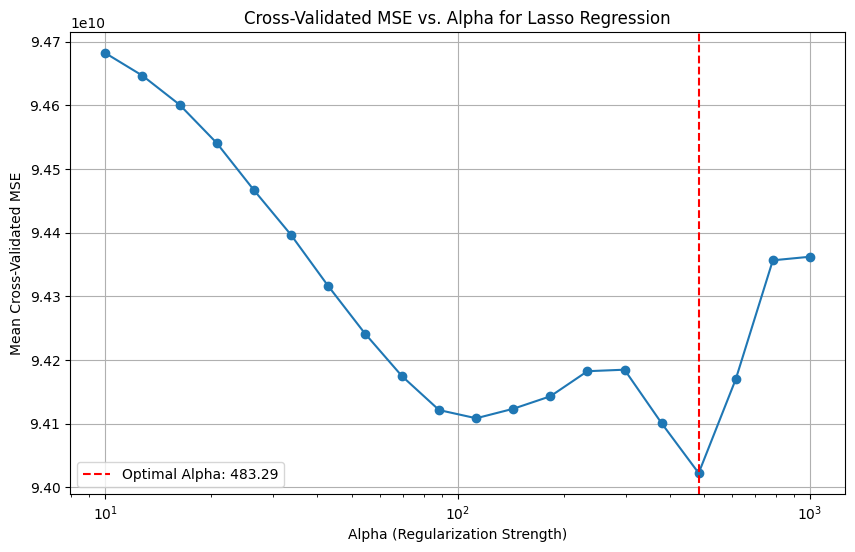

Optimal alpha: 483.29
Minimum MSE for optimal alpha: 25683393120.66


In [35]:
import matplotlib.pyplot as plt

mse_path = lasso_cv.mse_path_

mean_mse = mse_path.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(lasso_cv.alphas_, mean_mse, marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Cross-Validated MSE')
plt.title('Cross-Validated MSE vs. Alpha for Lasso Regression')
plt.grid(True)

plt.axvline(lasso_cv.alpha_, linestyle='--', color='red', label=f'Optimal Alpha: {lasso_cv.alpha_:.2f}')
plt.legend()
plt.show()

print(f"Optimal alpha: {lasso_cv.alpha_:.2f}")
print(f"Minimum MSE for optimal alpha: {lasso_cv.mse_path_.min():.2f}")

The localized dip in MSE at $\alpha \approx 483.29$ likely represents a point of feature sparsification, where the regularization strength becomes sufficient to zero out a non-generalizing higher-order term. While the model only has two base features, the 3rd-degree polynomial expansion created 9 separate features. The sudden drop in error suggests that removing one or more of these complex interaction or power terms eliminated specific noise that was hindering the model's performance. Furthermore, the discrepancy between the visual 9.40e10 (Mean CV MSE) and the written 2.56e10 is because the former averages across all 20 folds, while the latter reflects the single best-performing fold at that penalty level.

### Q2 - Part 5

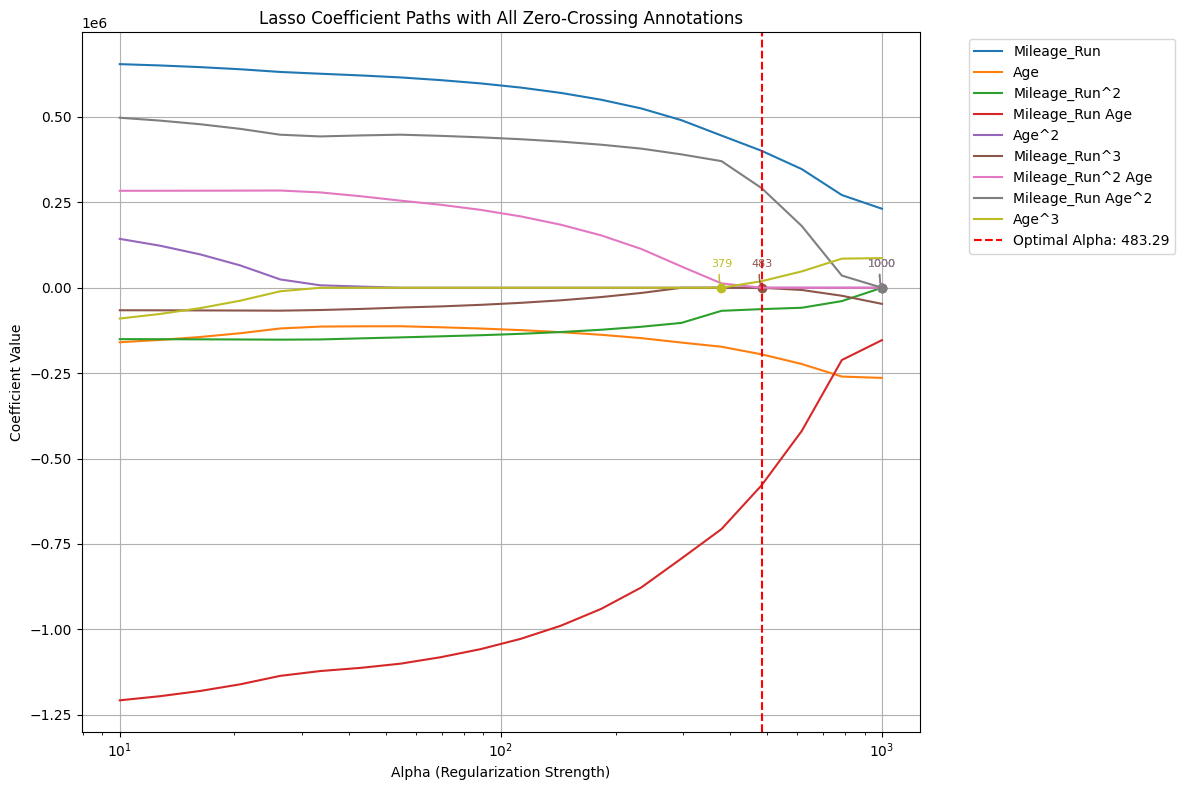

In [46]:
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path
import numpy as np

alphas_path, coef_paths, _ = lasso_path(X_q2_scaled_df, y_Q2, alphas=lasso_cv.alphas_, max_iter=10000)

plt.figure(figsize=(12, 8))

optimal_alpha = lasso_cv.alpha_

for i, feature in enumerate(X_q2_scaled_df.columns):
    line, = plt.plot(alphas_path, coef_paths[i], label=feature)
    line_color = line.get_color()

    zero_alpha = None
    for j in range(len(alphas_path) - 1, -1, -1):
        if abs(coef_paths[i, j]) < 1e-10:
            zero_alpha = alphas_path[j]
        else:
            if zero_alpha is not None:
                break

    if zero_alpha is not None:
        plt.plot(zero_alpha, 0, marker='o', color=line_color, markersize=6)
        plt.annotate(f'{zero_alpha:.0f}',
                     (zero_alpha, 0), textcoords="offset points", xytext=(0,15), ha='center',
                     fontsize=8, color=line_color, arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=.2', color=line_color))

plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths with All Zero-Crossing Annotations')
plt.axvline(optimal_alpha, color='red', linestyle='--', label=f'Optimal Alpha: {optimal_alpha:.2f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

This perfectly confirms my theory from the previous part. Age^3 becomes zero at $\alpha = 379$, representing where the decrease in MSE begins prior to the best $\alpha$. What is absolutely conclusive is that Mileage_Run^3 becomes zero at $\alpha = 483$, exactly where the lowest MSE and best $\alpha$ values were recorded. This demonstrates that Mileage_Run^3 was actually introducing too much complexity into the model, and its elimination was beneficial.

### Q2 - Part 6

In [47]:
selected_features = X_q2_scaled_df.columns[lasso_cv.coef_ != 0]
zero_coef_features = X_q2_scaled_df.columns[lasso_cv.coef_ == 0]

num_total_features = len(X_q2_scaled_df.columns)
num_zero_features = len(zero_coef_features)
proportion_zero = num_zero_features / num_total_features

print(f"Features selected (non-zero coefficients):\n{list(selected_features)}\n")
print(f"Features set to zero:\n{list(zero_coef_features)}\n")
print(f"Proportion of features set to zero: {proportion_zero:.2%}")

Features selected (non-zero coefficients):
['Mileage_Run', 'Age', 'Mileage_Run^2', 'Mileage_Run Age', 'Mileage_Run Age^2', 'Age^3']

Features set to zero:
['Age^2', 'Mileage_Run^3', 'Mileage_Run^2 Age']

Proportion of features set to zero: 33.33%


### Q2 - Part 7

In [50]:
lin_reg_coefs = pd.Series(lin_reg.coef_, index=X_q2_scaled_df.columns)
lasso_coefs = pd.Series(lasso_cv.coef_, index=X_q2_scaled_df.columns)

comparison_df = pd.DataFrame({
    'Linear Regression Coef': lin_reg_coefs,
    'Lasso Coef': lasso_coefs
})

print("Coefficient Comparison:")
display(comparison_df)

Coefficient Comparison:


,Linear Regression Coef,Lasso Coef
Mileage_Run,6.686165e+05,401025.259657
Age,-1.841941e+05,-194803.116695
Mileage_Run^2,-1.494679e+05,-62539.290093
Mileage_Run Age,-1.251592e+06,-578788.661090
Age^2,2.156399e+05,-0.000000
Mileage_Run^3,-6.514490e+04,-0.000000
Mileage_Run^2 Age,2.833392e+05,0.000000
Mileage_Run Age^2,5.280829e+05,292015.025679
Age^3,-1.389370e+05,19133.908573


Looking at the comparison table of linear regression coefficients and Lasso-regularized coefficients, almost all decrease in magnitude. However, Age^3 actually switches sign, and Age increases in magnitude. Without over-generalizing, the Age variable is more prominent at lower Age values, but the Age^3 variable increasing takes over as Age increases. With the Age coefficient becoming more negative, it indicates as new cars age they quickly lose value. However, at larger ages, the depreciation slows a lot, or the price even begins to rise again, potentially due to high-value classic cars. This much more complex trend is missed by the simple linear regression coefficients.

## **Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

### Q3 - Part 1

In [52]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

heart_df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
print("Original Heart Failure Data:")
display(heart_df.head())

num_features = ['age', 'ejection_fraction', 'serum_creatinine']
X_num = heart_df[num_features]

poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num_poly = poly_num.fit_transform(X_num)
poly_num_feature_names = poly_num.get_feature_names_out(num_features)

scaler_num = StandardScaler()
X_num_scaled = scaler_num.fit_transform(X_num_poly)
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=poly_num_feature_names)

print("\nScaled Polynomial Numerical Features:")
display(X_num_scaled_df.head())

cat_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
X_cat = heart_df[cat_features]

poly_cat_interaction = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_cat_interaction = poly_cat_interaction.fit_transform(X_cat)
poly_cat_interaction_feature_names = poly_cat_interaction.get_feature_names_out(cat_features)

X_cat_interaction_df = pd.DataFrame(X_cat_interaction, columns=poly_cat_interaction_feature_names)

print("\nInteraction-Only Categorical Features:")
display(X_cat_interaction_df.head())

X_q3_processed = pd.concat([X_num_scaled_df, X_cat_interaction_df], axis=1)
y_q3 = heart_df['DEATH_EVENT']

print("\nFinal Processed Feature Matrix (X_q3_processed):")
display(X_q3_processed.head())
print(f"Shape of final feature matrix: {X_q3_processed.shape}")


Original Heart Failure Data:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1



Scaled Polynomial Numerical Features:


,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,age^2 ejection_fraction,age^2 serum_creatinine,age ejection_fraction^2,age ejection_fraction serum_creatinine,age serum_creatinine^2,ejection_fraction^3,ejection_fraction^2 serum_creatinine,ejection_fraction serum_creatinine^2,serum_creatinine^3
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,-0.450915,0.942348,-1.049525,-0.134955,0.142821,-0.925154,-0.453114,-0.114940,-0.075575
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,-0.419260,-0.420054,-0.278632,-0.300976,-0.227841,-0.248601,-0.197693,-0.176609,-0.156017
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,-0.812686,-0.019293,-1.111920,-0.484473,-0.149244,-0.925154,-0.527114,-0.205256,-0.143415
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,-1.258439,-0.156737,-1.205513,-0.421199,-0.021000,-0.925154,-0.453114,-0.114940,-0.075575
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,-0.812686,1.075626,-1.111920,0.063909,0.511486,-0.925154,-0.354449,0.058167,0.111038



Interaction-Only Categorical Features:


,anaemia,diabetes,high_blood_pressure,smoking,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking,anaemia diabetes high_blood_pressure,anaemia diabetes smoking,anaemia high_blood_pressure smoking,diabetes high_blood_pressure smoking
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Final Processed Feature Matrix (X_q3_processed):


,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking,anaemia diabetes high_blood_pressure,anaemia diabetes smoking,anaemia high_blood_pressure smoking,diabetes high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Shape of final feature matrix: (299, 33)


### Q3 - Part 2

In [54]:
from sklearn.linear_model import LinearRegression
import pandas as pd

lin_reg_q3 = LinearRegression()
lin_reg_q3.fit(X_q3_processed, y_q3)

coefficients_q3 = pd.Series(lin_reg_q3.coef_, index=X_q3_processed.columns)

print("Linear Regression Coefficients for DEATH_EVENT:")
display(coefficients_q3.sort_values(ascending=False))

Linear Regression Coefficients for DEATH_EVENT:


,0
ejection_fraction^2,3.317931
ejection_fraction serum_creatinine,2.604767
age^3,1.889040
age serum_creatinine,1.680570
age,1.549928
age serum_creatinine^2,1.433246
ejection_fraction serum_creatinine^2,1.217335
age^2 ejection_fraction,1.022027
diabetes smoking,0.337922
diabetes high_blood_pressure,0.282831


Negative coefficients for the following all feel counterintuitive, as all are generally linked with a higher mortality rate:
- 'serum_creatinine'
- 'anaemia'
- 'diabetes'
- 'high_blood_pressure'
- 'smoking'

The inclusion of interactions and higher-order powers might solve this, as these relationships/variable are very rarely linear. For example, 'Age' and 'Age^3' are positive, which makes sense, but 'Age^2' isn't. At first glance this seems odd, but it actually results in a U-shaped pattern that understandably predicts high mortality for really young and really old, and lower mortality for those middle aged. This makes sense as children and the elderly are much more likely to suffer fatal effect from heart problems. Interactions also seem to add to the story, as many of the above-listed variable coefficients are negative by themselves, but are positive when incorporating 'Age' or 'Age^3'. This represents how something such as 'diabetes' is highly unlikely to cause fatal problems until late in life, something 'diabetes' by itself can't show.

### Q3 - Part 3

In [59]:
import numpy as np
from sklearn.linear_model import LassoCV

alphas_q3 = np.logspace(-5, 5, 30)

lasso_cv_q3 = LassoCV(alphas=alphas_q3, cv=20, random_state=100, n_jobs=-1, max_iter=100000)

lasso_cv_q3.fit(X_q3_processed, y_q3)

print(f"Optimal alpha: {lasso_cv_q3.alpha_:.4f}")
print(f"Minimum MSE for optimal alpha: {lasso_cv_q3.mse_path_.min():.4f}")

Optimal alpha: 0.0057
Minimum MSE for optimal alpha: 0.0686


### Q3 - Part 4

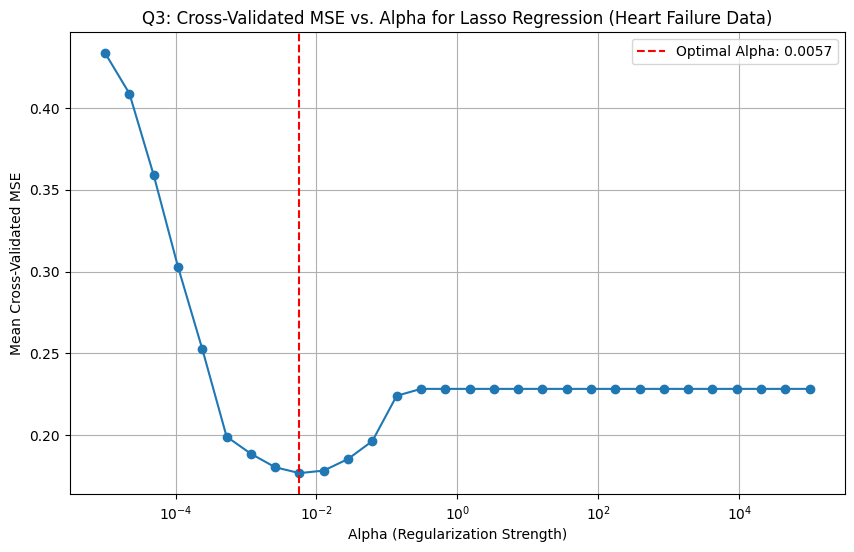

Optimal alpha: 0.0057
Minimum MSE for optimal alpha: 0.0686


In [61]:
import matplotlib.pyplot as plt

mse_path_q3 = lasso_cv_q3.mse_path_
mean_mse_q3 = mse_path_q3.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(lasso_cv_q3.alphas_, mean_mse_q3, marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Cross-Validated MSE')
plt.title('Q3: Cross-Validated MSE vs. Alpha for Lasso Regression (Heart Failure Data)')
plt.grid(True)

plt.axvline(lasso_cv_q3.alpha_, linestyle='--', color='red', label=f'Optimal Alpha: {lasso_cv_q3.alpha_:.4f}')
plt.legend()
plt.show()

print(f"Optimal alpha: {lasso_cv_q3.alpha_:.4f}")
print(f"Minimum MSE for optimal alpha: {lasso_cv_q3.mse_path_.min():.4f}")

This graph follows a much more understandable pattern than the last, indicating that there likely isn't a feature whose coefficient goes to 0 at the point of the optimal alpha.

### Q3 - Part 5

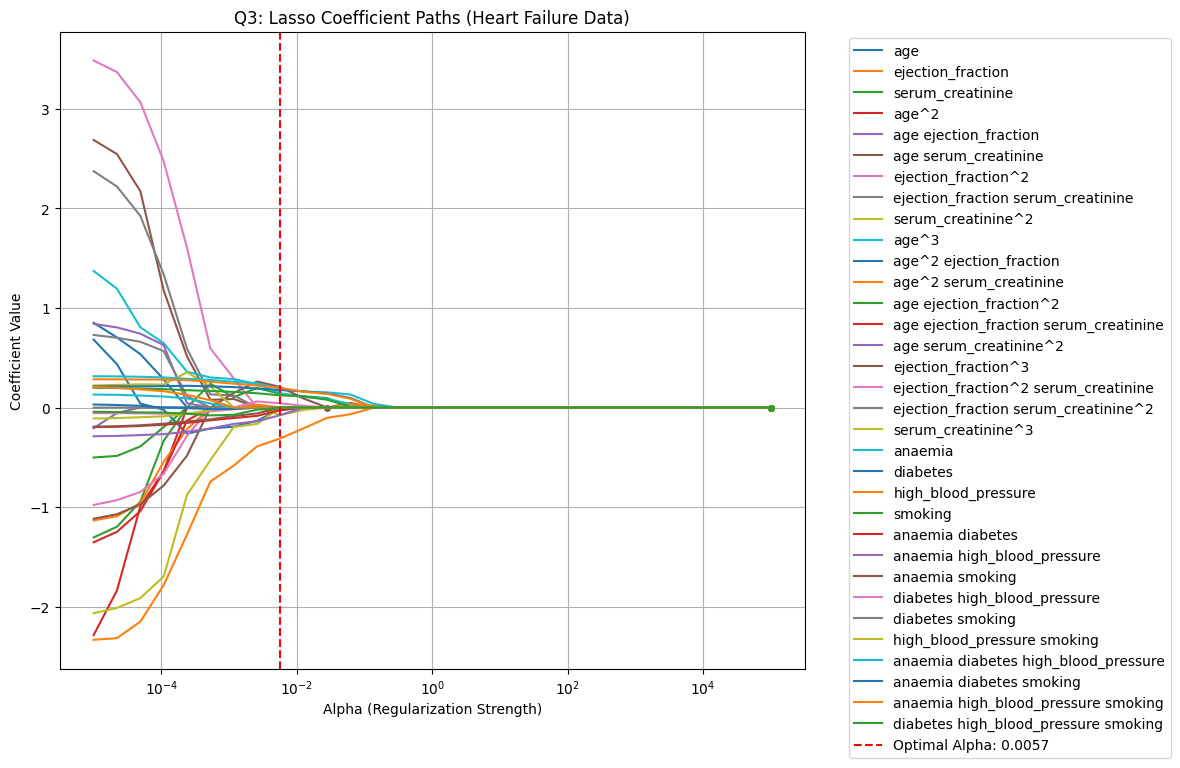

In [71]:
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path
import numpy as np

alphas_path_q3, coef_paths_q3, _ = lasso_path(X_q3_processed, y_q3, alphas=lasso_cv_q3.alphas_, max_iter=100000)

plt.figure(figsize=(12, 8))

optimal_alpha_q3 = lasso_cv_q3.alpha_

for i, feature in enumerate(X_q3_processed.columns):
    line, = plt.plot(alphas_path_q3, coef_paths_q3[i], label=feature)
    line_color = line.get_color()

    zero_alpha_point = None
    for j in range(len(alphas_path_q3) - 1, -1, -1):
        if abs(coef_paths_q3[i, j]) < 1e-10: # Check if coefficient is effectively zero
            zero_alpha_point = alphas_path_q3[j]
        else:
            if zero_alpha_point is not None:
                break

    if zero_alpha_point is not None and zero_alpha_point >= optimal_alpha_q3:
        # Only annotate if it goes to zero at or after the optimal alpha
        plt.plot(zero_alpha_point, 0, marker='o', color=line_color, markersize=4)


plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Q3: Lasso Coefficient Paths (Heart Failure Data)')
plt.axvline(optimal_alpha_q3, color='red', linestyle='--', label=f'Optimal Alpha: {optimal_alpha_q3:.4f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

For the sake of better visualization, I want to zoom in slightly on the most important region, as there is a lot of clutter.

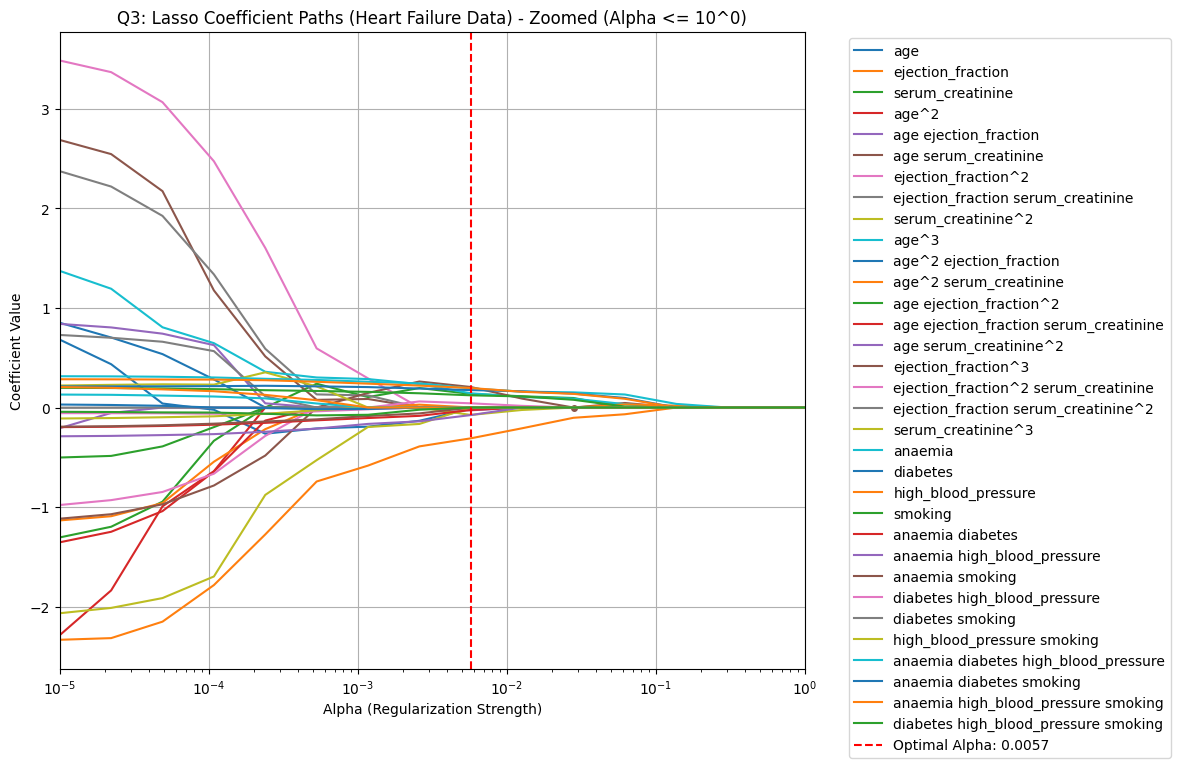

In [70]:
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path
import numpy as np

alphas_path_q3, coef_paths_q3, _ = lasso_path(X_q3_processed, y_q3, alphas=lasso_cv_q3.alphas_, max_iter=100000)

plt.figure(figsize=(12, 8))

optimal_alpha_q3 = lasso_cv_q3.alpha_

for i, feature in enumerate(X_q3_processed.columns):
    line, = plt.plot(alphas_path_q3, coef_paths_q3[i], label=feature)
    line_color = line.get_color()

    zero_alpha_point = None
    for j in range(len(alphas_path_q3) - 1, -1, -1):
        if abs(coef_paths_q3[i, j]) < 1e-10: # Check if coefficient is effectively zero
            zero_alpha_point = alphas_path_q3[j]
        else:
            if zero_alpha_point is not None:
                break

    if zero_alpha_point is not None and zero_alpha_point >= optimal_alpha_q3:
        # Only annotate if it goes to zero at or after the optimal alpha
        plt.plot(zero_alpha_point, 0, marker='o', color=line_color, markersize=4)


plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Q3: Lasso Coefficient Paths (Heart Failure Data) - Zoomed (Alpha <= 10^0)')
plt.axvline(optimal_alpha_q3, color='red', linestyle='--', label=f'Optimal Alpha: {optimal_alpha_q3:.4f}')
plt.xlim([1e-5, 1]) # Set x-axis limit to zoom in
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

It appears as though almost all coefficients go to 0 in this region, and a majority are 0 at the best $\alpha$

### Q3 - Part 6

In [68]:
import pandas as pd
import numpy as np

selected_features_q3 = X_q3_processed.columns[lasso_cv_q3.coef_ != 0]
zero_coef_features_q3 = X_q3_processed.columns[lasso_cv_q3.coef_ == 0]

num_total_features_q3 = len(X_q3_processed.columns)
num_zero_features_q3 = len(zero_coef_features_q3)
proportion_zero_q3 = num_zero_features_q3 / num_total_features_q3

print(f"Features selected (non-zero coefficients) at optimal alpha ({lasso_cv_q3.alpha_:.4f}):")
print(list(selected_features_q3))
print("\nFeatures set to zero:")
print(list(zero_coef_features_q3))
print(f"\nProportion of features set to zero: {proportion_zero_q3:.2%}")

lin_reg_q3_coefs = pd.Series(lin_reg_q3.coef_, index=X_q3_processed.columns)
lasso_q3_coefs = pd.Series(lasso_cv_q3.coef_, index=X_q3_processed.columns)

comparison_df_q3 = pd.DataFrame({
    'Linear Regression Coef': lin_reg_q3_coefs,
    'Lasso Coef': lasso_q3_coefs
})

print("\nCoefficient Comparison:")
display(comparison_df_q3.sort_values(by='Lasso Coef', ascending=False))


Features selected (non-zero coefficients) at optimal alpha (0.0057):
['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']

Features set to zero:
['age', 'age^2', 'age ejection_fraction', 'age serum_creatinine', 'ejection_fraction^2', 'ejection_fraction serum_creatinine', 'serum_creatinine^2', 'age^2 ejection_fraction', 'age^2 serum_creatinine', 'age ejection_fraction^2', 'age ejection_fraction serum_creatinine', 'age serum_creatinine^2', 'ejection_fraction serum_creatinine^2', 'smoking', 'anaemia diabetes', 'anaemia high_blood_pressure', 'anaemia smoking', 'anaemia diabetes high_blood_pressure', 'anaemia diabetes smoking', 'anaemia high_blood_pressure smoking', 'diabetes high_blood_pressure smoking']

Proportion of features set to zero: 63.64%

Coefficient Comparison:


,Linear Regression Coef,Lasso Coef
ejection_fraction^3,-1.253594,0.204822
age^3,1.889040,0.117992
serum_creatinine,-0.739027,0.116875
diabetes high_blood_pressure,0.282831,0.053968
ejection_fraction^2 serum_creatinine,-1.219271,0.032801
high_blood_pressure smoking,0.213817,0.017805
anaemia,-0.043420,0.014178
high_blood_pressure,-0.073480,0.013608
diabetes smoking,0.337922,0.003466
diabetes,-0.149472,0.000607


As displayed in the above output, 63.64% of the coefficients went to 0, indicating the majority of features aren't considered. However, of the ones that remained, roughly half flipped sign. The breakdown of the changes is below:
- Decrease in Magnitude:
  - Age^3
  - diabetes high_blood_pressue
  - high_blood_pressue smoking
  - diabetes smoking
  - ejection_fraction
- Sign Flip
  - ejection_fraction^3
  - serum_creatinine
  - ejection_fraction^2 serum_creatinine
  - anaemia
  - high_blood_pressure
  - diabetes
- Increase in Magnitude
  - serum_creatinine^3

Interestingly, almost all of the negative coefficients initially highlighted as being counterintuitive flipped sign. This indicates that the Lasso coefficients make more sense that the linear regression coefficients and better predict mortality. This leaves the Lasso sign patterns making far more sense. From the persepctive of bias-variance trade-off, I previously discussed how linear regression (unregularized) is high variance and low bias, whereas Lasso (reguarized) is low variance and high bias. This is seen here, as the majority of the features are eliminated, vastly reducing bias. This allows the once counterintuitive featurs (the most important ones), to take a great role, creating a higher bias towards them. In the sense of this problem, the simple variables are the most important, as there correlation with mortality is relatively high and straightforward. This is why the Lasso model is able to give much more intuitive sign patterns.

## **Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

### Q4 - Part 1

### Q4 - Part 2

### Q4 - Part 3

### Q4 - Part 4